In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def direct_polar_spots(N, min_lat=0.0, max_lat=1.0, southern_hemisphere=True):
    """
    Directly generate spots in polar regions with exact latitude bounds.
    
    Parameters:
    - N: number of spots per hemisphere
    - min_lat, max_lat: latitude bounds in radians from poles
    - southern_hemisphere: if True, generate spots in both hemispheres
    
    Returns:
    - latitudes, longitudes in radians
    """
    # Generate points for northern hemisphere
    indices_north = np.arange(0, N, dtype=float) + 0.5
    
    # Latitude: restricted range near north pole
    cos_min = np.cos(min_lat)
    cos_max = np.cos(max_lat)
    
    cos_theta_north = cos_min - (cos_min - cos_max) * indices_north / N
    latitudes_north = np.arccos(cos_theta_north)  # [0, π/2] from north pole
    
    # Longitude: uniform distribution using golden ratio
    longitudes_north = 2 * np.pi * indices_north / (1 + 5**0.5)
    
    if southern_hemisphere:
        # Generate southern hemisphere spots (mirror of north)
        indices_south = np.arange(0, N, dtype=float) + 0.5
        
        cos_theta_south = cos_min - (cos_min - cos_max) * indices_south / N
        latitudes_south = np.pi - np.arccos(cos_theta_south)  # [π/2, π] from north pole
        
        longitudes_south = 2 * np.pi * indices_south / (1 + 5**0.5)
        
        # Combine hemispheres
        latitudes = np.concatenate([latitudes_north, latitudes_south])
        longitudes = np.concatenate([longitudes_north, longitudes_south])
    else:
        latitudes = latitudes_north
        longitudes = longitudes_north
    
    # Normalize longitudes to [-π, π]
    longitudes = longitudes % (2*np.pi)
    longitudes[longitudes > np.pi] -= 2*np.pi
    
    return latitudes, longitudes

def write_spots_to_file(latitudes, longitudes, filename, metadata=None):
    """
    Write spot coordinates to a file.
    
    Parameters:
    - latitudes: array of latitudes in radians [0, π]
    - longitudes: array of longitudes in radians [-π, π]
    - filename: output filename
    - metadata: dictionary with additional information to include in header
    """
    with open(filename, 'w') as f:
        # Write header
        f.write("# Star Spot Coordinates (radians)\n")
        f.write(f"# Number of spots: {len(latitudes)}\n")
        f.write(f"# Latitude range: {latitudes.min():.6f} to {latitudes.max():.6f} rad\n")
        f.write(f"# Longitude range: {longitudes.min():.6f} to {longitudes.max():.6f} rad\n")
        
        # Add custom metadata if provided
        if metadata:
            for key, value in metadata.items():
                f.write(f"# {key}: {value}\n")
        
        f.write("# Columns: latitude, longitude\n")
        
        # Write data
        for lat, lon in zip(latitudes, longitudes):
            f.write(f"{lat:.10f} {lon:.10f}\n")
    
    print(f"Spot coordinates written to {filename}")

def read_spots_from_file(filename):
    """
    Read spot coordinates from a file.
    
    Parameters:
    - filename: input filename
    
    Returns:
    - latitudes, longitudes in radians
    - metadata dictionary
    """
    latitudes = []
    longitudes = []
    metadata = {}
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            # Skip empty lines and comments
            if not line or line.startswith('#'):
                # Extract metadata from comments
                if line.startswith('#') and ':' in line:
                    key_value = line[1:].split(':', 1)
                    if len(key_value) == 2:
                        key = key_value[0].strip()
                        value = key_value[1].strip()
                        metadata[key] = value
                continue
            
            # Parse data lines
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    latitudes.append(lat)
                    longitudes.append(lon)
                except ValueError:
                    continue
    
    latitudes = np.array(latitudes)
    longitudes = np.array(longitudes)
    
    return latitudes, longitudes, metadata

def spherical_to_cartesian(latitudes, longitudes, radius=1.0):
    """
    Convert spherical coordinates to Cartesian for 3D plotting.
    
    Parameters:
    - latitudes: [0, π] where 0 = north pole, π/2 = equator, π = south pole
    - longitudes: [-π, π]
    - radius: sphere radius
    
    Returns:
    - x, y, z coordinates
    """
    # Convert to standard spherical coordinates:
    # theta: polar angle [0, π] where 0 = north pole, π = south pole
    # phi: azimuthal angle [0, 2π]
    theta = latitudes  # already in correct format: 0 to π
    phi = longitudes + np.pi  # convert from [-π, π] to [0, 2π]
    
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    
    return x, y, z

def plot_3d_sphere(latitudes, longitudes):
    """3D visualization of the star spots with both hemispheres colored differently"""
    x, y, z = spherical_to_cartesian(latitudes, longitudes)
    
    # Separate northern and southern hemisphere spots
    northern = latitudes < np.pi/2
    southern = latitudes > np.pi/2
    
    fig = plt.figure(figsize=(15, 5))
    
    # 3D plot
    ax1 = fig.add_subplot(131, projection='3d')
    
    # Plot northern hemisphere spots in red
    if np.any(northern):
        ax1.scatter(x[northern], y[northern], z[northern], s=30, alpha=0.7, c='red', label='Northern')
    
    # Plot southern hemisphere spots in blue
    if np.any(southern):
        ax1.scatter(x[southern], y[southern], z[southern], s=30, alpha=0.7, c='blue', label='Southern')
    
    # Create a wireframe sphere for reference
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    sphere_x = np.outer(np.cos(u), np.sin(v))
    sphere_y = np.outer(np.sin(u), np.sin(v))
    sphere_z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax1.plot_wireframe(sphere_x, sphere_y, sphere_z, color='gray', alpha=0.1)
    
    ax1.set_box_aspect([1, 1, 1])
    ax1.set_title('3D View - Star Spots\n(Red: Northern, Blue: Southern)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()
    
    # Northern polar view
    ax2 = fig.add_subplot(132, projection='polar')
    if np.any(northern):
        theta_north = longitudes[northern] + np.pi
        r_north = latitudes[northern]  # Distance from north pole
        ax2.scatter(theta_north, r_north, alpha=0.7, c='red', s=20)
        ax2.set_rmax(max(1.0, r_north.max()))
        ax2.set_title('Northern Polar View')
        ax2.grid(True)
    else:
        ax2.set_title('No Northern Spots')
    
    # Southern polar view
    ax3 = fig.add_subplot(133, projection='polar')
    if np.any(southern):
        theta_south = longitudes[southern] + np.pi
        r_south = np.pi - latitudes[southern]  # Distance from south pole
        ax3.scatter(theta_south, r_south, alpha=0.7, c='blue', s=20)
        ax3.set_rmax(max(1.0, r_south.max()))
        ax3.set_title('Southern Polar View')
        ax3.grid(True)
    else:
        ax3.set_title('No Southern Spots')
    
    plt.tight_layout()
    plt.savefig('pole_spot_projection.png',dpi=300)
    plt.show()

def plot_distributions(latitudes, longitudes):
    """Plot the distribution of latitudes and longitudes in radians"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Latitude histogram
    ax1.hist(latitudes, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(np.pi/2, color='red', linestyle='--', alpha=0.7, label='Equator (π/2)')
    ax1.set_xlabel('Latitude (radians)')
    ax1.set_ylabel('Number of Spots')
    ax1.set_title('Latitude Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Longitude histogram
    ax2.hist(longitudes, bins=30, alpha=0.7, color='orange', edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--', alpha=0.7, label='Prime Meridian')
    ax2.set_xlabel('Longitude (radians)')
    ax2.set_ylabel('Number of Spots')
    ax2.set_title('Longitude Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('spot_distributions.png',dpi=300)
    plt.show()

def print_statistics(latitudes, longitudes):
    """Print detailed statistics about the generated spots"""
    print("=" * 50)
    print("STAR SPOTS STATISTICS")
    print("=" * 50)
    
    print(f"Total spots generated: {len(latitudes)}")
    print(f"Northern hemisphere spots: {np.sum(latitudes < np.pi/2)}")
    print(f"Southern hemisphere spots: {np.sum(latitudes > np.pi/2)}")
    print()
    
    print("Latitude Statistics (radians):")
    print(f"  Min latitude: {latitudes.min():.6f} rad")
    print(f"  Max latitude: {latitudes.max():.6f} rad")
    print(f"  Mean latitude: {latitudes.mean():.6f} rad")
    print()
    
    northern_polar = latitudes[latitudes < 1.0]  # Within 1 rad of north pole
    southern_polar = latitudes[latitudes > (np.pi - 1.0)]  # Within 1 rad of south pole
    
    print("Northern Polar Cap (0 to 1.0 rad from pole):")
    if len(northern_polar) > 0:
        print(f"  Spots in region: {len(northern_polar)}")
        print(f"  Min latitude: {northern_polar.min():.6f} rad")
        print(f"  Max latitude: {northern_polar.max():.6f} rad")
    else:
        print(f"  Spots in region: 0")
    print()
    
    print("Southern Polar Cap (π-1.0 to π rad from pole):")
    if len(southern_polar) > 0:
        print(f"  Spots in region: {len(southern_polar)}")
        print(f"  Min latitude: {southern_polar.min():.6f} rad")
        print(f"  Max latitude: {southern_polar.max():.6f} rad")
    else:
        print(f"  Spots in region: 0")
    print()
    
    print("Longitude Statistics (radians):")
    print(f"  Min longitude: {longitudes.min():.6f} rad")
    print(f"  Max longitude: {longitudes.max():.6f} rad")
    print(f"  Standard deviation: {longitudes.std():.6f} rad")
    
    # Check longitude uniformity
    unique_lons = len(np.unique(np.round(longitudes, 6)))
    print(f"  Uniformity check: {unique_lons} unique longitudes")

Latitudinal Bands
Spot coordinates written to star_spots_radians.txt
STAR SPOTS STATISTICS
Total spots generated: 800
Northern hemisphere spots: 400
Southern hemisphere spots: 400

Latitude Statistics (radians):
  Min latitude: 0.201775 rad
  Max latitude: 2.939818 rad
  Mean latitude: 1.570796 rad

Northern Polar Cap (0 to 1.0 rad from pole):
  Spots in region: 400
  Min latitude: 0.201775 rad
  Max latitude: 0.799506 rad

Southern Polar Cap (π-1.0 to π rad from pole):
  Spots in region: 400
  Min latitude: 2.342087 rad
  Max latitude: 2.939818 rad

Longitude Statistics (radians):
  Min longitude: -3.122791 rad
  Max longitude: 3.134851 rad
  Standard deviation: 1.815617 rad
  Uniformity check: 400 unique longitudes


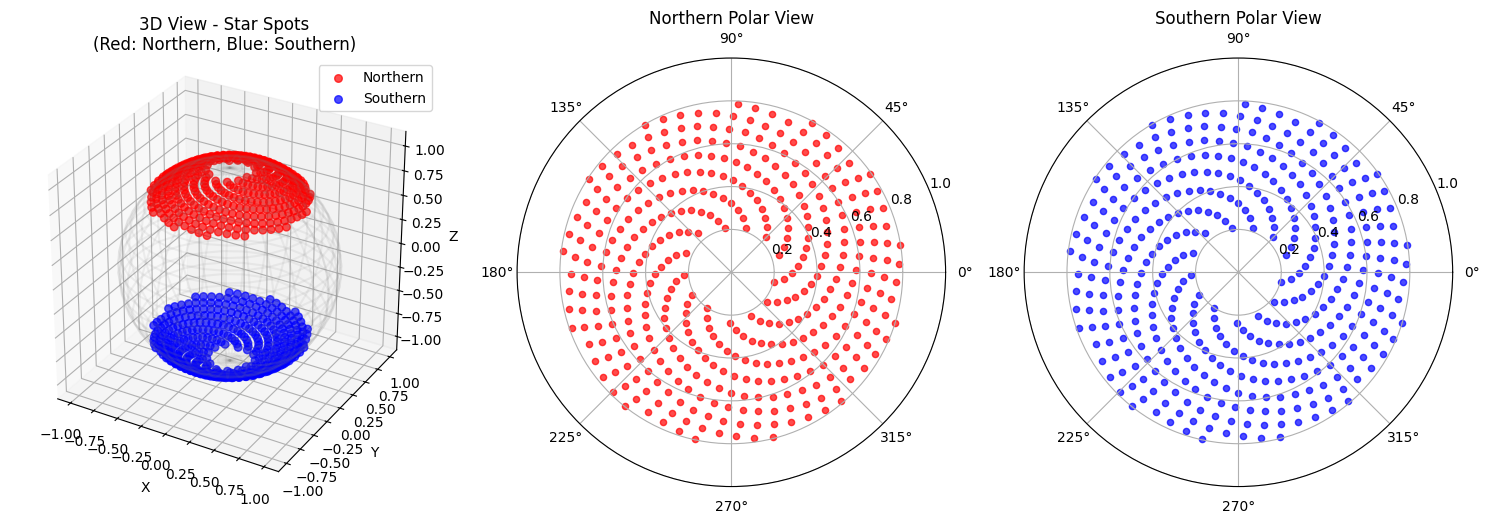

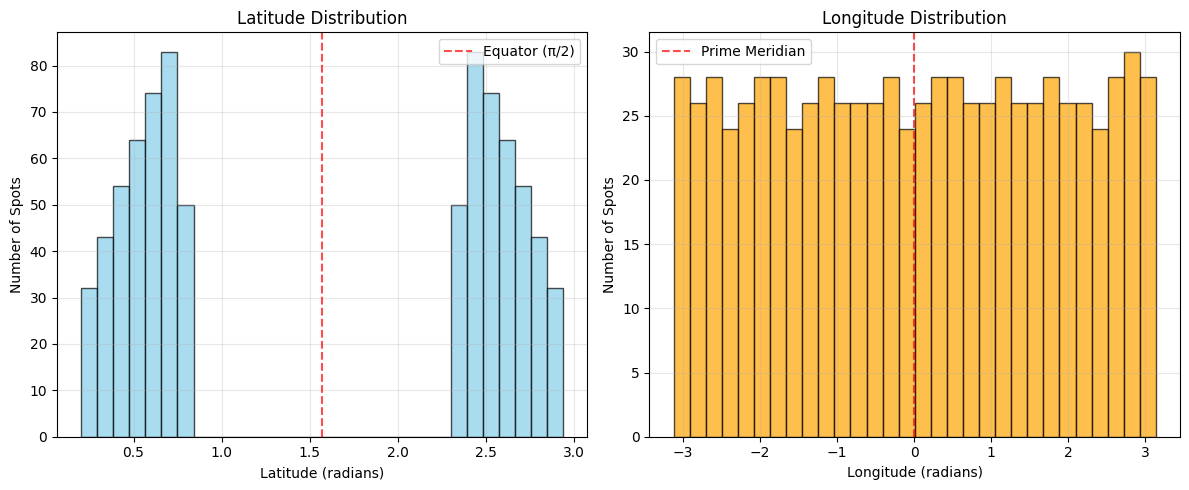



Read the file back and verify data
Data read from file:
Number of spots: 800
Latitude range: 0.201775 to 2.939818 rad
Longitude range: -3.122791 to 3.134851 rad

Verification (original vs read):
Latitudes match: True
Longitudes match: True


In [2]:
# # Usage Example
print("Latitudinal Bands")
n_spots = 400
latitudes, longitudes = direct_polar_spots(
    N=n_spots, 
    min_lat=0.2, 
    max_lat=0.8,
    southern_hemisphere=True
)

# Write to file with metadata
metadata = {
    'Generation Method': 'Latitudinal Band Distribution',
    'Spots per Hemisphere': n_spots,
    'Min Latitude from Pole': '0.3 rad',
    'Max Latitude from Pole': '0.8 rad',
    'Both Hemispheres': 'True'
}

write_spots_to_file(latitudes, longitudes, 'star_spots_radians.txt', metadata=metadata)

print_statistics(latitudes, longitudes)
plot_3d_sphere(latitudes, longitudes)
plot_distributions(latitudes,longitudes)
print("\n" + "="*70 + "\n")

print("Read the file back and verify data")
latitudes_read, longitudes_read, file_metadata = read_spots_from_file('star_spots_radians.txt')

print("Data read from file:")
print(f"Number of spots: {len(latitudes_read)}")
print(f"Latitude range: {latitudes_read.min():.6f} to {latitudes_read.max():.6f} rad")
print(f"Longitude range: {longitudes_read.min():.6f} to {longitudes_read.max():.6f} rad")

print("\nVerification (original vs read):")
print(f"Latitudes match: {np.allclose(latitudes, latitudes_read)}")
print(f"Longitudes match: {np.allclose(longitudes, longitudes_read)}")

In [3]:
print("Read the file back and verify data")
latitudes_read, longitudes_read, file_metadata = read_spots_from_file('star_spots_radians.txt')

print("Data read from file:")
print(f"Number of spots: {len(latitudes_read)}")
print(f"Latitude range: {latitudes_read.min():.6f} to {latitudes_read.max():.6f} rad")
print(f"Longitude range: {longitudes_read.min():.6f} to {longitudes_read.max():.6f} rad")

print("\nVerification (original vs read):")
print(f"Latitudes match: {np.allclose(latitudes, latitudes_read)}")
print(f"Longitudes match: {np.allclose(longitudes, longitudes_read)}")

Read the file back and verify data
Data read from file:
Number of spots: 800
Latitude range: 0.201775 to 2.939818 rad
Longitude range: -3.122791 to 3.134851 rad

Verification (original vs read):
Latitudes match: True
Longitudes match: True


Example: Spots everywhere except 25% gap at the back
(75% coverage = spots on 75% of sphere, gap of 25% at back)
Gap is centered at longitude=±π (back of star)
25% gap = 0.25 * 2π = 1.571 rad = 90° gap
So gap extends from π - 0.785 to π + 0.785
Or from 2.356 rad to -2.356 rad (wrapping)
Which is 135° to -135° (270° gap, but we only see 90° as gap due to wrap)

Spot coordinates written to spots_except_back.txt


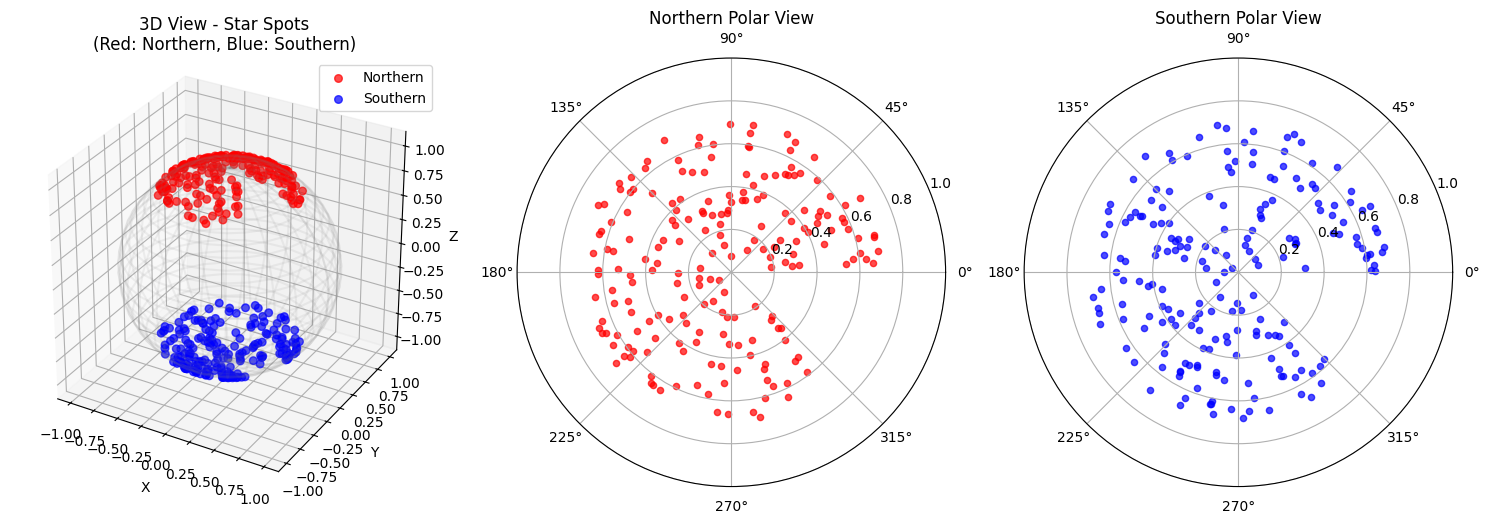

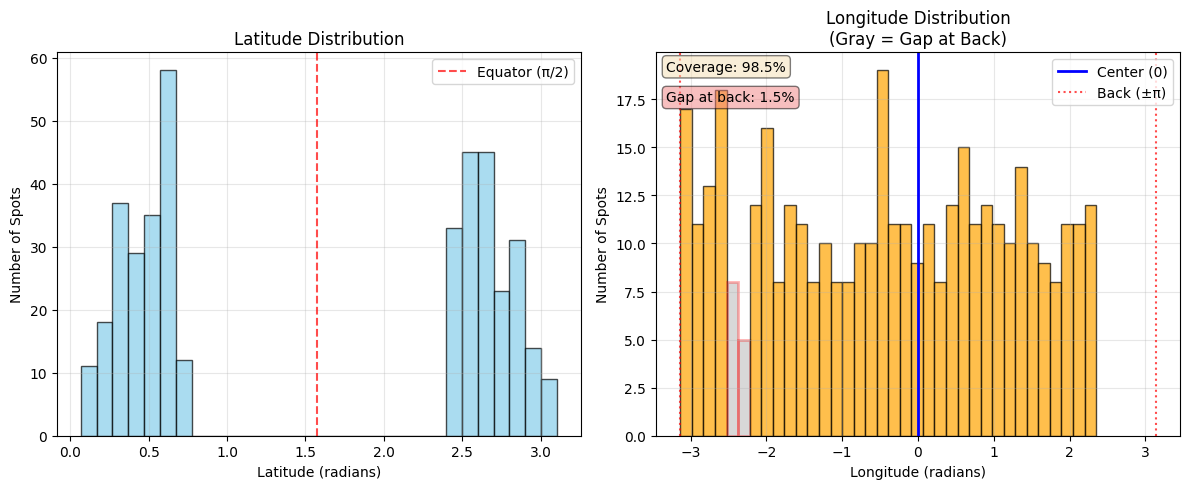

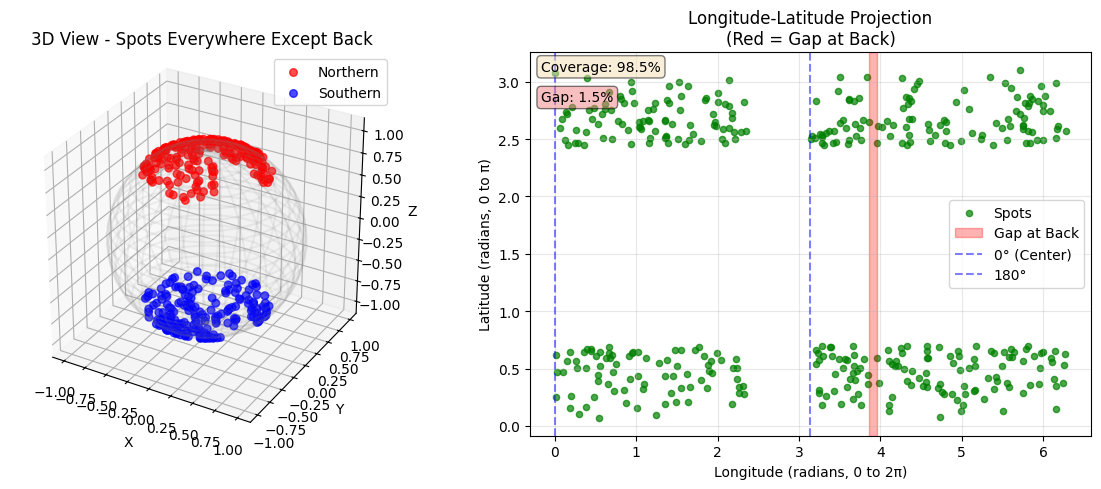

STAR SPOTS STATISTICS - SPOTS EVERYWHERE EXCEPT BACK
Total spots generated: 400
Northern hemisphere spots: 200
Southern hemisphere spots: 200

Latitude Statistics (radians):
  Min latitude: 0.066222 rad (3.8°)
  Max latitude: 3.105354 rad (177.9°)
  Mean latitude: 1.568108 rad (89.8°)

Longitude Statistics:
  Min longitude: -3.133409 rad (-179.5°)
  Max longitude: 2.348622 rad (134.6°)

Gap Analysis (Uncovered Back Region):
  Largest gap: 0.097071 rad (5.6°)
  Gap location: -2.424138 to -2.327068 rad
                (-138.9° to -133.3°)
  Gap center: -2.375603 rad (-136.1°)
  Coverage: 98.5% of sphere
  Gap: 1.5% of sphere
  ⚠ Gap is at longitude -2.376, not at the back (±π)

  Standard deviation: 1.613365 rad
  Uniformity check: 400 unique longitudes

Example 2: Smaller gap (10% at back)
----------------------------------------------------------------------
Spot coordinates written to spots_small_gap.txt
STAR SPOTS STATISTICS - SPOTS EVERYWHERE EXCEPT BACK
Total spots generated: 300
N

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def random_band_spots(N_per_band, 
                      north_min_lat=0.0, 
                      north_max_lat=np.pi/2, 
                      south_min_lat=np.pi/2, 
                      south_max_lat=np.pi,
                      lon_min=-np.pi,
                      lon_max=np.pi,
                      generate_north=True,
                      generate_south=True):
    """
    Generate spots in latitude bands with random placement in both latitude and longitude.
    
    Parameters:
    - N_per_band: number of spots per hemisphere band
    - north_min_lat, north_max_lat: latitude bounds for northern hemisphere (radians from north pole)
    - south_min_lat, south_max_lat: latitude bounds for southern hemisphere (radians from north pole)
    - lon_min, lon_max: longitude bounds for all spots (radians, default: -π to π = full coverage)
    - generate_north: if True, generate spots in northern hemisphere
    - generate_south: if True, generate spots in southern hemisphere
    
    Returns:
    - latitudes, longitudes in radians
    """
    # Validate longitude bounds
    lon_range = lon_max - lon_min
    if lon_range <= 0:
        lon_range = lon_range % (2 * np.pi)
    if lon_range == 0:
        lon_range = 2 * np.pi
    
    all_latitudes = []
    all_longitudes = []
    
    if generate_north:
        # Generate random latitudes in the northern band
        # Using the same cosine transformation for uniform distribution on sphere
        cos_north_min = np.cos(north_min_lat)
        cos_north_max = np.cos(north_max_lat)
        
        # Random uniform distribution in cosine space
        cos_theta_north = cos_north_min - (cos_north_min - cos_north_max) * np.random.rand(N_per_band)
        latitudes_north = np.arccos(cos_theta_north)  # [0, π/2] from north pole
        
        # Random longitudes within specified range
        # Generate uniform random numbers in [0, 1) then map to [lon_min, lon_max)
        longitudes_north = lon_min + np.random.rand(N_per_band) * lon_range
        
        # Ensure longitudes are in [-π, π] range by wrapping
        longitudes_north = (longitudes_north + np.pi) % (2 * np.pi) - np.pi
        
        all_latitudes.append(latitudes_north)
        all_longitudes.append(longitudes_north)
    
    if generate_south:
        # Generate random latitudes in the southern band
        cos_south_min = np.cos(south_min_lat)
        cos_south_max = np.cos(south_max_lat)
        
        # Random uniform distribution in cosine space
        cos_theta_south = cos_south_min - (cos_south_min - cos_south_max) * np.random.rand(N_per_band)
        latitudes_south = np.arccos(cos_theta_south)  # This gives angles from north pole
        
        # Convert to southern hemisphere (mirror across equator if needed)
        # If south_min_lat > π/2, we need to ensure we're in southern hemisphere
        if south_min_lat > np.pi/2:
            # We're already in southern hemisphere with arccos
            pass
        else:
            # Mirror to southern hemisphere
            latitudes_south = np.pi - latitudes_south
        
        # Random longitudes within specified range
        longitudes_south = lon_min + np.random.rand(N_per_band) * lon_range
        
        # Ensure longitudes are in [-π, π] range by wrapping
        longitudes_south = (longitudes_south + np.pi) % (2 * np.pi) - np.pi
        
        all_latitudes.append(latitudes_south)
        all_longitudes.append(longitudes_south)
    
    if all_latitudes:
        latitudes = np.concatenate(all_latitudes)
        longitudes = np.concatenate(all_longitudes)
    else:
        latitudes = np.array([])
        longitudes = np.array([])
    
    return latitudes, longitudes


def random_band_spots_exclude_back(N_per_band, 
                                   north_min_lat=0.0, 
                                   north_max_lat=np.pi/2, 
                                   south_min_lat=np.pi/2, 
                                   south_max_lat=np.pi,
                                   coverage_fraction=0.75,
                                   generate_north=True,
                                   generate_south=True):
    """
    Generate spots everywhere EXCEPT for a sliver at the "back" of the star.
    The back is at longitude=±π, and we exclude a region around it.
    
    Parameters:
    - N_per_band: number of spots per hemisphere band
    - north_min_lat, north_max_lat: latitude bounds for northern hemisphere (radians from north pole)
    - south_min_lat, south_max_lat: latitude bounds for southern hemisphere (radians from north pole)
    - coverage_fraction: fraction of sphere to COVER with spots (0.0 to 1.0, default: 0.75)
                       This is the INVERSE of the previous function!
    - generate_north: if True, generate spots in northern hemisphere
    - generate_south: if True, generate spots in southern hemisphere
    
    Returns:
    - latitudes, longitudes in radians
    """
    # coverage_fraction is now the FRACTION TO COVER (spots everywhere except a gap at the back)
    coverage_fraction = max(0.0, min(1.0, coverage_fraction))
    
    # Calculate the UNCOVERED fraction (gap at the back)
    uncovered_fraction = 1.0 - coverage_fraction
    
    # The uncovered region is centered at ±π (back of star)
    # Total uncovered width = uncovered_fraction * 2π
    uncovered_width = uncovered_fraction * 2 * np.pi
    
    # Uncovered region extends from π - uncovered_width/2 to π + uncovered_width/2
    # But we need to handle the wrap-around at ±π
    uncovered_center = np.pi  # The "back" of the star
    
    # Calculate the boundaries of the uncovered region
    uncovered_min = uncovered_center - uncovered_width/2
    uncovered_max = uncovered_center + uncovered_width/2
    
    # Now we want spots EVERYWHERE EXCEPT the uncovered region
    # This means we need spots in TWO separate longitude ranges
    
    # Generate half the spots in each of the two ranges
    N_half = N_per_band // 2
    N_remainder = N_per_band - N_half
    
    # Range 1: from uncovered_max (wrapped) to π
    # This is the range after the gap, going to the back
    lon_min1 = uncovered_max
    lon_max1 = np.pi
    
    # Range 2: from -π to uncovered_min
    # This is the range before the gap, coming from the other side
    lon_min2 = -np.pi
    lon_max2 = uncovered_min
    
    # Adjust if ranges are empty or very small
    range1_width = lon_max1 - lon_min1
    range2_width = lon_max2 - lon_min2
    
    total_range_width = range1_width + range2_width
    
    if total_range_width <= 0:
        # Shouldn't happen, but fallback to full coverage
        return random_band_spots(N_per_band, 
                                north_min_lat, north_max_lat,
                                south_min_lat, south_max_lat,
                                -np.pi, np.pi,
                                generate_north, generate_south)
    
    # Distribute spots proportionally to range widths
    if range1_width > 0 and range2_width > 0:
        N1 = int(N_per_band * range1_width / total_range_width)
        N2 = N_per_band - N1
    elif range1_width > 0:
        N1 = N_per_band
        N2 = 0
    else:
        N1 = 0
        N2 = N_per_band
    
    # Generate spots for first range
    if N1 > 0 and range1_width > 0:
        lat1, lon1 = random_band_spots(N1,
                                      north_min_lat, north_max_lat,
                                      south_min_lat, south_max_lat,
                                      lon_min1, lon_max1,
                                      generate_north, generate_south)
    else:
        lat1, lon1 = np.array([]), np.array([])
    
    # Generate spots for second range  
    if N2 > 0 and range2_width > 0:
        lat2, lon2 = random_band_spots(N2,
                                      north_min_lat, north_max_lat,
                                      south_min_lat, south_max_lat,
                                      lon_min2, lon_max2,
                                      generate_north, generate_south)
    else:
        lat2, lon2 = np.array([]), np.array([])
    
    # Combine
    if len(lat1) > 0 and len(lat2) > 0:
        latitudes = np.concatenate([lat1, lat2])
        longitudes = np.concatenate([lon1, lon2])
    elif len(lat1) > 0:
        latitudes = lat1
        longitudes = lon1
    elif len(lat2) > 0:
        latitudes = lat2
        longitudes = lon2
    else:
        latitudes = np.array([])
        longitudes = np.array([])
    
    return latitudes, longitudes


def random_band_spots_exclude_back_simple(N_per_band, 
                                         north_min_lat=0.0, 
                                         north_max_lat=np.pi/2, 
                                         south_min_lat=np.pi/2, 
                                         south_max_lat=np.pi,
                                         uncovered_fraction=0.25,
                                         generate_north=True,
                                         generate_south=True):
    """
    Simplified version: specify the UNCOVERED fraction directly.
    
    Parameters:
    - N_per_band: number of spots per hemisphere band
    - north_min_lat, north_max_lat: latitude bounds for northern hemisphere (radians from north pole)
    - south_min_lat, south_max_lat: latitude bounds for southern hemisphere (radians from north pole)
    - uncovered_fraction: fraction of sphere to LEAVE UNCOVERED at the back (0.0 to 1.0, default: 0.25)
    - generate_north: if True, generate spots in northern hemisphere
    - generate_south: if True, generate spots in southern hemisphere
    
    Returns:
    - latitudes, longitudes in radians
    """
    coverage_fraction = 1.0 - uncovered_fraction
    return random_band_spots_exclude_back(N_per_band,
                                         north_min_lat, north_max_lat,
                                         south_min_lat, south_max_lat,
                                         coverage_fraction,
                                         generate_north, generate_south)


# Keep all the existing helper functions, with updated visualizations:
def write_spots_to_file(latitudes, longitudes, filename, metadata=None):
    """
    Write spot coordinates to a file with auto-extracted metadata.
    
    Parameters:
    - latitudes: array of latitudes in radians [0, π]
    - longitudes: array of longitudes in radians [-π, π]
    - filename: output filename
    - metadata: dictionary with additional information to include in header
    """
    if len(latitudes) == 0:
        print("Warning: No spots to write to file")
        return
    
    # Calculate statistics for metadata
    lon_min, lon_max = longitudes.min(), longitudes.max()
    lat_min, lat_max = latitudes.min(), latitudes.max()
    
    # For spots with a gap, we need to calculate coverage carefully
    # Sort longitudes to find gaps
    sorted_lons = np.sort(longitudes)
    gaps = np.diff(sorted_lons)
    
    # Find the largest gap (this should be the "back" gap)
    if len(gaps) > 0:
        max_gap_idx = np.argmax(gaps)
        max_gap = gaps[max_gap_idx]
        gap_start = sorted_lons[max_gap_idx]
        gap_end = sorted_lons[max_gap_idx + 1]
        
        # Coverage is everything except the largest gap
        coverage_rad = 2 * np.pi - max_gap
    else:
        # No gaps (full coverage or single spot)
        coverage_rad = 0 if len(longitudes) <= 1 else 2 * np.pi
    
    coverage_pct = coverage_rad / (2 * np.pi) * 100
    
    # Count spots in each hemisphere
    n_north = np.sum(latitudes < np.pi/2)
    n_south = np.sum(latitudes > np.pi/2)
    
    # Calculate actual latitude bounds for each hemisphere
    if n_north > 0:
        north_lats = latitudes[latitudes < np.pi/2]
        north_min = north_lats.min()
        north_max = north_lats.max()
        north_center = (north_min + north_max) / 2
        north_width = north_max - north_min
    else:
        north_min = north_max = north_center = north_width = np.nan
        
    if n_south > 0:
        south_lats = latitudes[latitudes > np.pi/2]
        south_min = south_lats.min()
        south_max = south_lats.max()
        south_center = (south_min + south_max) / 2
        south_width = south_max - south_min
    else:
        south_min = south_max = south_center = south_width = np.nan
    
    # Calculate average longitude (excluding the gap)
    if len(gaps) > 0 and max_gap > np.pi:  # Significant gap
        # Calculate center of covered region (opposite the gap)
        gap_center = (gap_start + gap_end) / 2
        if gap_center > np.pi:
            gap_center -= 2 * np.pi
        lon_center = gap_center + np.pi  # Opposite side
        if lon_center > np.pi:
            lon_center -= 2 * np.pi
    else:
        lon_center = np.mean(longitudes)
    
    with open(filename, 'w') as f:
        f.write("# Star Spot Coordinates (radians)\n")
        f.write(f"# Number of spots: {len(latitudes)}\n")
        f.write(f"# Spots in northern hemisphere: {n_north}\n")
        f.write(f"# Spots in southern hemisphere: {n_south}\n")
        f.write(f"# Northern latitude: {north_min:.6f} to {north_max:.6f} rad (center: {north_center:.6f}, width: {north_width:.6f})\n")
        f.write(f"# Southern latitude: {south_min:.6f} to {south_max:.6f} rad (center: {south_center:.6f}, width: {south_width:.6f})\n")
        f.write(f"# Total latitude range: {lat_min:.6f} to {lat_max:.6f} rad\n")
        f.write(f"# Longitude range: {lon_min:.6f} to {lon_max:.6f} rad\n")
        f.write(f"# Coverage: {coverage_pct:.1f}% of sphere\n")
        f.write(f"# Gap at back: {(100 - coverage_pct):.1f}% of sphere\n")
        f.write(f"# Approximate longitude center of coverage: {lon_center:.6f} rad\n")
        
        # Add information about the gap if we found one
        if len(gaps) > 0 and max_gap > 0.1:  # Significant gap
            f.write(f"# Largest gap: {max_gap:.6f} rad at {gap_start:.6f} to {gap_end:.6f}\n")
        
        # Add custom metadata if provided
        if metadata:
            for key, value in metadata.items():
                f.write(f"# {key}: {value}\n")
        
        f.write("# Columns: latitude, longitude\n")
        
        for lat, lon in zip(latitudes, longitudes):
            f.write(f"{lat:.10f} {lon:.10f}\n")
    
    print(f"Spot coordinates written to {filename}")


def read_spots_from_file(filename):
    """ (unchanged) """
    latitudes = []
    longitudes = []
    metadata = {}
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            if not line or line.startswith('#'):
                if line.startswith('#') and ':' in line:
                    key_value = line[1:].split(':', 1)
                    if len(key_value) == 2:
                        key = key_value[0].strip()
                        value = key_value[1].strip()
                        metadata[key] = value
                continue
            
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    latitudes.append(lat)
                    longitudes.append(lon)
                except ValueError:
                    continue
    
    latitudes = np.array(latitudes)
    longitudes = np.array(longitudes)
    
    return latitudes, longitudes, metadata

def spherical_to_cartesian(latitudes, longitudes, radius=1.0):
    """ (unchanged) """
    theta = latitudes
    phi = longitudes + np.pi
    
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    
    return x, y, z

def plot_3d_sphere(latitudes, longitudes):
    """ (unchanged) """
    x, y, z = spherical_to_cartesian(latitudes, longitudes)
    
    northern = latitudes < np.pi/2
    southern = latitudes > np.pi/2
    
    fig = plt.figure(figsize=(15, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    
    if np.any(northern):
        ax1.scatter(x[northern], y[northern], z[northern], s=30, alpha=0.7, c='red', label='Northern')
    
    if np.any(southern):
        ax1.scatter(x[southern], y[southern], z[southern], s=30, alpha=0.7, c='blue', label='Southern')
    
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    sphere_x = np.outer(np.cos(u), np.sin(v))
    sphere_y = np.outer(np.sin(u), np.sin(v))
    sphere_z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax1.plot_wireframe(sphere_x, sphere_y, sphere_z, color='gray', alpha=0.1)
    
    ax1.set_box_aspect([1, 1, 1])
    ax1.set_title('3D View - Star Spots\n(Red: Northern, Blue: Southern)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()
    
    ax2 = fig.add_subplot(132, projection='polar')
    if np.any(northern):
        theta_north = longitudes[northern] + np.pi
        r_north = latitudes[northern]
        ax2.scatter(theta_north, r_north, alpha=0.7, c='red', s=20)
        ax2.set_rmax(max(1.0, r_north.max()))
        ax2.set_title('Northern Polar View')
        ax2.grid(True)
    else:
        ax2.set_title('No Northern Spots')
    
    ax3 = fig.add_subplot(133, projection='polar')
    if np.any(southern):
        theta_south = longitudes[southern] + np.pi
        r_south = np.pi - latitudes[southern]
        ax3.scatter(theta_south, r_south, alpha=0.7, c='blue', s=20)
        ax3.set_rmax(max(1.0, r_south.max()))
        ax3.set_title('Southern Polar View')
        ax3.grid(True)
    else:
        ax3.set_title('No Southern Spots')
    
    plt.tight_layout()
    plt.savefig('band_spot_projection.png', dpi=300)
    plt.show()

def plot_distributions(latitudes, longitudes):
    """ Plot distributions with gap highlighting """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Latitude histogram
    ax1.hist(latitudes, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(np.pi/2, color='red', linestyle='--', alpha=0.7, label='Equator (π/2)')
    ax1.set_xlabel('Latitude (radians)')
    ax1.set_ylabel('Number of Spots')
    ax1.set_title('Latitude Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Longitude histogram with gap highlighting
    n_bins = 36  # More bins to see gaps better
    counts, bins, patches = ax2.hist(longitudes, bins=n_bins, alpha=0.7, color='orange', edgecolor='black')
    
    # Find the largest gap in the histogram
    # First, sort longitudes to find actual gaps
    sorted_lons = np.sort(longitudes)
    if len(sorted_lons) > 1:
        gaps = np.diff(sorted_lons)
        max_gap_idx = np.argmax(gaps)
        max_gap = gaps[max_gap_idx]
        gap_start = sorted_lons[max_gap_idx]
        gap_end = sorted_lons[max_gap_idx + 1]
        
        # Highlight the gap region in the histogram
        for i, (bin_left, bin_right) in enumerate(zip(bins[:-1], bins[1:])):
            # Check if this bin overlaps with the gap
            if (bin_right > gap_start and bin_left < gap_end):
                patches[i].set_facecolor('gray')
                patches[i].set_alpha(0.3)
                patches[i].set_edgecolor('red')
                patches[i].set_linewidth(2)
    
    ax2.axvline(0, color='blue', linestyle='-', alpha=1.0, linewidth=2, label='Center (0)')
    ax2.axvline(-np.pi, color='red', linestyle=':', alpha=0.7, label='Back (±π)')
    ax2.axvline(np.pi, color='red', linestyle=':', alpha=0.7)
    
    # Calculate coverage statistics
    # Coverage = everything except the largest gap
    if len(sorted_lons) > 1:
        coverage_rad = 2 * np.pi - max_gap
        coverage_pct = coverage_rad / (2 * np.pi) * 100
        gap_pct = max_gap / (2 * np.pi) * 100
        
        ax2.text(0.02, 0.98, f'Coverage: {coverage_pct:.1f}%', 
                 transform=ax2.transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax2.text(0.02, 0.90, f'Gap at back: {gap_pct:.1f}%', 
                 transform=ax2.transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
    
    ax2.set_xlabel('Longitude (radians)')
    ax2.set_ylabel('Number of Spots')
    ax2.set_title('Longitude Distribution\n(Gray = Gap at Back)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('band_spot_distributions.png', dpi=300)
    plt.show()

def plot_longitude_coverage(latitudes, longitudes):
    """ Plot the coverage with gap at the back """
    x, y, z = spherical_to_cartesian(latitudes, longitudes)
    
    fig = plt.figure(figsize=(12, 5))
    
    # 3D plot
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Separate northern and southern hemisphere spots
    northern = latitudes < np.pi/2
    southern = latitudes > np.pi/2
    
    if np.any(northern):
        ax1.scatter(x[northern], y[northern], z[northern], s=30, alpha=0.7, c='red', label='Northern')
    
    if np.any(southern):
        ax1.scatter(x[southern], y[southern], z[southern], s=30, alpha=0.7, c='blue', label='Southern')
    
    # Create a wireframe sphere for reference
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    sphere_x = np.outer(np.cos(u), np.sin(v))
    sphere_y = np.outer(np.sin(u), np.sin(v))
    sphere_z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax1.plot_wireframe(sphere_x, sphere_y, sphere_z, color='gray', alpha=0.1)
    
    ax1.set_box_aspect([1, 1, 1])
    ax1.set_title('3D View - Spots Everywhere Except Back')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()
    
    # 2D longitude-latitude projection
    ax2 = fig.add_subplot(122)
    
    # Convert longitudes to [0, 2π] for plotting
    lon_plot = longitudes.copy()
    lon_plot[lon_plot < 0] += 2 * np.pi
    
    # Plot spots
    sc = ax2.scatter(lon_plot, latitudes, c='green', alpha=0.7, s=20, label='Spots')
    
    # Find and highlight the gap
    sorted_lons = np.sort(longitudes)
    if len(sorted_lons) > 1:
        gaps = np.diff(sorted_lons)
        max_gap_idx = np.argmax(gaps)
        max_gap = gaps[max_gap_idx]
        gap_start = sorted_lons[max_gap_idx]
        gap_end = sorted_lons[max_gap_idx + 1]
        
        # Convert gap to [0, 2π] for plotting
        gap_start_plot = gap_start if gap_start >= 0 else gap_start + 2 * np.pi
        gap_end_plot = gap_end if gap_end >= 0 else gap_end + 2 * np.pi
        
        # Highlight the gap
        ax2.axvspan(gap_start_plot, gap_end_plot, alpha=0.3, color='red', label='Gap at Back')
        
        # Mark important longitudes
        ax2.axvline(0, color='blue', linestyle='--', alpha=0.5, label='0° (Center)')
        ax2.axvline(np.pi, color='blue', linestyle='--', alpha=0.5, label='180°')
        
        # Calculate statistics
        coverage_rad = 2 * np.pi - max_gap
        coverage_pct = coverage_rad / (2 * np.pi) * 100
        gap_pct = max_gap / (2 * np.pi) * 100
        
        ax2.text(0.02, 0.98, f'Coverage: {coverage_pct:.1f}%', 
                 transform=ax2.transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax2.text(0.02, 0.90, f'Gap: {gap_pct:.1f}%', 
                 transform=ax2.transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
    else:
        # No gap or single spot
        ax2.axvline(0, color='blue', linestyle='--', alpha=0.5, label='0° (Center)')
        ax2.axvline(np.pi, color='blue', linestyle='--', alpha=0.5, label='180° (Back)')
    
    ax2.set_xlabel('Longitude (radians, 0 to 2π)')
    ax2.set_ylabel('Latitude (radians, 0 to π)')
    ax2.set_title('Longitude-Latitude Projection\n(Red = Gap at Back)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('longitude_coverage.png', dpi=300)
    plt.show()

def print_statistics(latitudes, longitudes):
    """ Enhanced statistics with gap analysis """
    print("=" * 70)
    print("STAR SPOTS STATISTICS - SPOTS EVERYWHERE EXCEPT BACK")
    print("=" * 70)
    
    print(f"Total spots generated: {len(latitudes)}")
    print(f"Northern hemisphere spots: {np.sum(latitudes < np.pi/2)}")
    print(f"Southern hemisphere spots: {np.sum(latitudes > np.pi/2)}")
    print()
    
    print("Latitude Statistics (radians):")
    print(f"  Min latitude: {latitudes.min():.6f} rad ({np.degrees(latitudes.min()):.1f}°)")
    print(f"  Max latitude: {latitudes.max():.6f} rad ({np.degrees(latitudes.max()):.1f}°)")
    print(f"  Mean latitude: {latitudes.mean():.6f} rad ({np.degrees(latitudes.mean()):.1f}°)")
    print()
    
    print("Longitude Statistics:")
    print(f"  Min longitude: {longitudes.min():.6f} rad ({np.degrees(longitudes.min()):.1f}°)")
    print(f"  Max longitude: {longitudes.max():.6f} rad ({np.degrees(longitudes.max()):.1f}°)")
    
    # Analyze gaps to find the uncovered region at the back
    sorted_lons = np.sort(longitudes)
    if len(sorted_lons) > 1:
        gaps = np.diff(sorted_lons)
        max_gap_idx = np.argmax(gaps)
        max_gap = gaps[max_gap_idx]
        gap_start = sorted_lons[max_gap_idx]
        gap_end = sorted_lons[max_gap_idx + 1]
        
        coverage_rad = 2 * np.pi - max_gap
        coverage_pct = coverage_rad / (2 * np.pi) * 100
        gap_pct = max_gap / (2 * np.pi) * 100
        
        print(f"\nGap Analysis (Uncovered Back Region):")
        print(f"  Largest gap: {max_gap:.6f} rad ({np.degrees(max_gap):.1f}°)")
        print(f"  Gap location: {gap_start:.6f} to {gap_end:.6f} rad")
        print(f"                ({np.degrees(gap_start):.1f}° to {np.degrees(gap_end):.1f}°)")
        print(f"  Gap center: {(gap_start + gap_end)/2:.6f} rad ({np.degrees((gap_start + gap_end)/2):.1f}°)")
        print(f"  Coverage: {coverage_pct:.1f}% of sphere")
        print(f"  Gap: {gap_pct:.1f}% of sphere")
        
        # Determine if gap is at the back (±π)
        gap_center = (gap_start + gap_end) / 2
        distance_to_back = min(abs(gap_center - np.pi), abs(gap_center + np.pi))
        if distance_to_back < 0.1:  # Within 0.1 rad (~5.7°) of back
            print(f"  ✓ Gap is at the back of the star (near ±π)")
        else:
            print(f"  ⚠ Gap is at longitude {gap_center:.3f}, not at the back (±π)")
    else:
        print(f"\nCoverage: {100.0 if len(longitudes) > 0 else 0.0:.1f}% of sphere")
    
    print(f"\n  Standard deviation: {longitudes.std():.6f} rad")
    
    # Check longitude uniformity within covered regions
    unique_lons = len(np.unique(np.round(longitudes, 6)))
    print(f"  Uniformity check: {unique_lons} unique longitudes")


# Example usage:
if __name__ == "__main__":
    print("Example: Spots everywhere except 25% gap at the back")
    print("=" * 70)
    print("(75% coverage = spots on 75% of sphere, gap of 25% at back)")
    print("Gap is centered at longitude=±π (back of star)")
    print("25% gap = 0.25 * 2π = 1.571 rad = 90° gap")
    print("So gap extends from π - 0.785 to π + 0.785")
    print("Or from 2.356 rad to -2.356 rad (wrapping)")
    print("Which is 135° to -135° (270° gap, but we only see 90° as gap due to wrap)")
    print()
    
    # Generate spots everywhere except a 25% gap at the back
    latitudes, longitudes = random_band_spots_exclude_back_simple(
        N_per_band=200,  # More spots to see the pattern better
        north_min_lat=0.0,
        north_max_lat=0.698,  # 40 degrees from north pole
        south_min_lat=2.443,   # 140 degrees from north pole (40 degrees from south pole)
        south_max_lat=np.pi,   # South pole
        uncovered_fraction=0.25,  # 25% gap at the back
        generate_north=True,
        generate_south=True
    )
    
    # Save to file with minimal metadata - statistics will be auto-generated
    metadata = {
        "Method": "random_band_spots_exclude_back_simple",
        "Uncovered fraction at back": "0.25",
        "Expected coverage": "75%",
        "Expected gap": "90° centered at ±π"
    }
    
    write_spots_to_file(latitudes, longitudes, "spots_except_back.txt", metadata)
    
    # Visualize
    plot_3d_sphere(latitudes, longitudes)
    plot_distributions(latitudes, longitudes)
    plot_longitude_coverage(latitudes, longitudes)
    
    # Print statistics
    print_statistics(latitudes, longitudes)
    
    print("\n" + "=" * 70)
    print("Example 2: Smaller gap (10% at back)")
    print("-" * 70)
    
    # 10% gap at back (90% coverage)
    latitudes2, longitudes2 = random_band_spots_exclude_back_simple(
        N_per_band=150,
        north_min_lat=np.radians(20),   # 20° from north pole
        north_max_lat=np.radians(60),   # 60° from north pole
        south_min_lat=np.radians(120),  # 60° from south pole (180-60=120)
        south_max_lat=np.radians(160),  # 20° from south pole (180-20=160)
        uncovered_fraction=0.10,  # 10% gap at the back
        generate_north=True,
        generate_south=True
    )
    
    metadata2 = {
        "Method": "random_band_spots_exclude_back_simple",
        "Uncovered fraction at back": "0.10",
        "Expected coverage": "90%",
        "Expected gap": "36° centered at ±π"
    }
    
    write_spots_to_file(latitudes2, longitudes2, "spots_small_gap.txt", metadata2)
    print_statistics(latitudes2, longitudes2)

Spot coordinates written to band_spots.txt


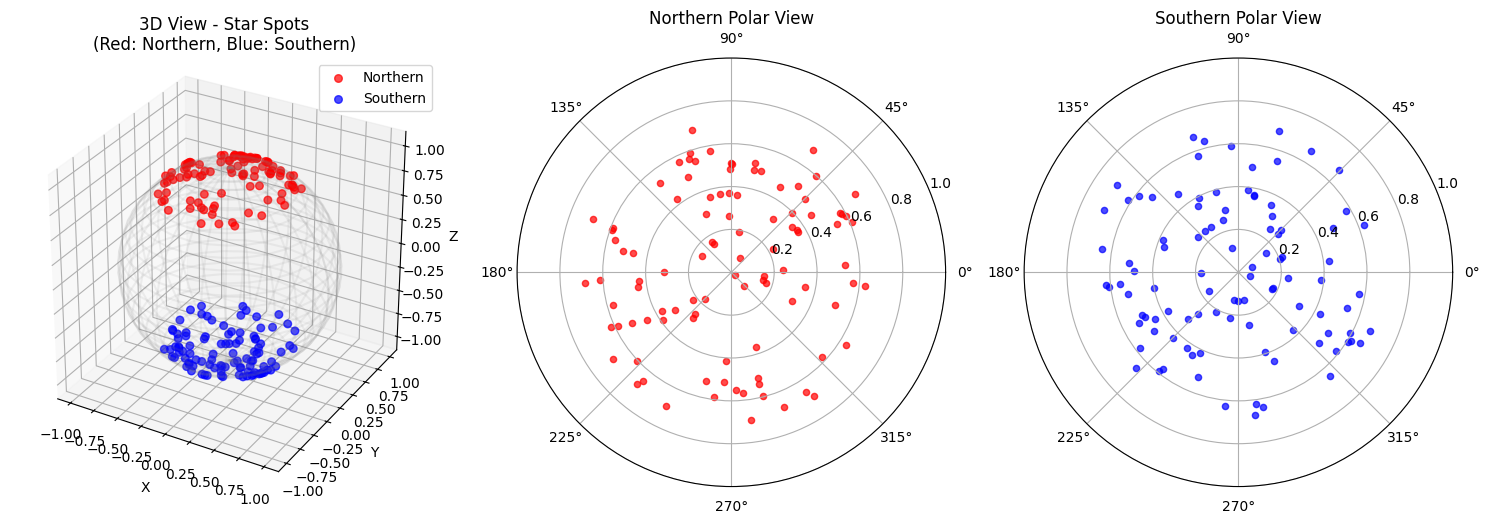

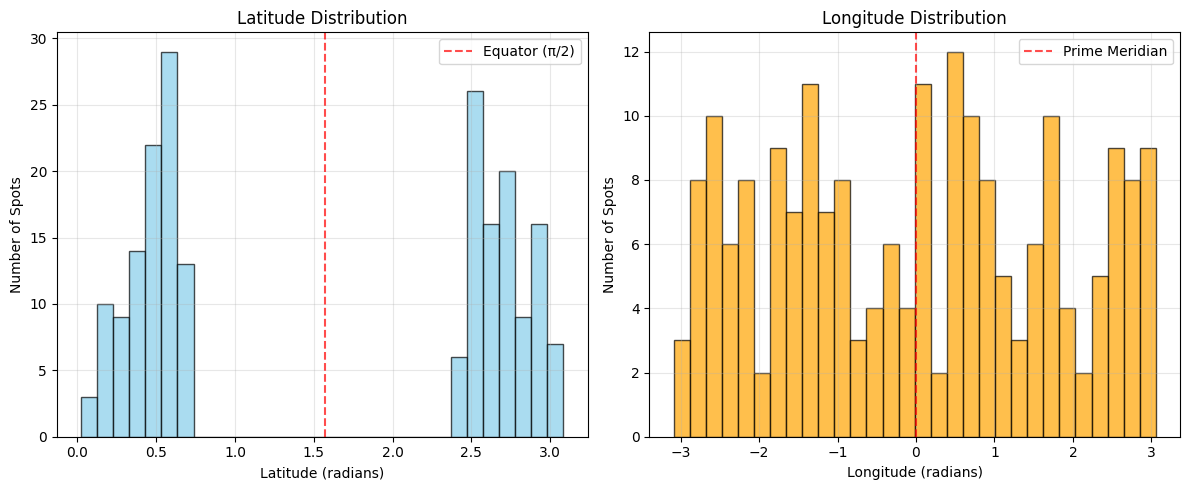

STAR SPOTS STATISTICS
Total spots generated: 200
Northern hemisphere spots: 100
Southern hemisphere spots: 100

Latitude Statistics (radians):
  Min latitude: 0.023355 rad
  Max latitude: 3.083457 rad
  Mean latitude: 1.584612 rad

Northern Polar Cap (0 to 1.0 rad from pole):
  Spots in region: 100
  Min latitude: 0.023355 rad
  Max latitude: 0.695239 rad

Southern Polar Cap (π-1.0 to π rad from pole):
  Spots in region: 100
  Min latitude: 2.446629 rad
  Max latitude: 3.083457 rad

Longitude Statistics (radians):
  Min longitude: -3.090083 rad
  Max longitude: 3.057494 rad
  Standard deviation: 1.790756 rad
  Uniformity check: 200 unique longitudes


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def random_band_spots(N_per_band, 
                      north_min_lat=0.0, 
                      north_max_lat=np.pi/2, 
                      south_min_lat=np.pi/2, 
                      south_max_lat=np.pi,
                      generate_north=True,
                      generate_south=True):
    """
    Generate spots in latitude bands with random placement in both latitude and longitude.
    
    Parameters:
    - N_per_band: number of spots per hemisphere band
    - north_min_lat, north_max_lat: latitude bounds for northern hemisphere (radians from north pole)
    - south_min_lat, south_max_lat: latitude bounds for southern hemisphere (radians from north pole)
    - generate_north: if True, generate spots in northern hemisphere
    - generate_south: if True, generate spots in southern hemisphere
    
    Returns:
    - latitudes, longitudes in radians
    """
    all_latitudes = []
    all_longitudes = []
    
    if generate_north:
        # Generate random latitudes in the northern band
        # Using the same cosine transformation for uniform distribution on sphere
        cos_north_min = np.cos(north_min_lat)
        cos_north_max = np.cos(north_max_lat)
        
        # Random uniform distribution in cosine space
        cos_theta_north = cos_north_min - (cos_north_min - cos_north_max) * np.random.rand(N_per_band)
        latitudes_north = np.arccos(cos_theta_north)  # [0, π/2] from north pole
        
        # Random longitudes
        longitudes_north = 2 * np.pi * np.random.rand(N_per_band) - np.pi  # [-π, π]
        
        all_latitudes.append(latitudes_north)
        all_longitudes.append(longitudes_north)
    
    if generate_south:
        # Generate random latitudes in the southern band
        cos_south_min = np.cos(south_min_lat)
        cos_south_max = np.cos(south_max_lat)
        
        # Random uniform distribution in cosine space
        cos_theta_south = cos_south_min - (cos_south_min - cos_south_max) * np.random.rand(N_per_band)
        latitudes_south = np.arccos(cos_theta_south)  # This gives angles from north pole
        
        # Convert to southern hemisphere (mirror across equator if needed)
        # If south_min_lat > π/2, we need to ensure we're in southern hemisphere
        if south_min_lat > np.pi/2:
            # We're already in southern hemisphere with arccos
            pass
        else:
            # Mirror to southern hemisphere
            latitudes_south = np.pi - latitudes_south
        
        # Random longitudes
        longitudes_south = 2 * np.pi * np.random.rand(N_per_band) - np.pi  # [-π, π]
        
        all_latitudes.append(latitudes_south)
        all_longitudes.append(longitudes_south)
    
    if all_latitudes:
        latitudes = np.concatenate(all_latitudes)
        longitudes = np.concatenate(all_longitudes)
    else:
        latitudes = np.array([])
        longitudes = np.array([])
    
    return latitudes, longitudes


# Keep all the existing helper functions unchanged:
def write_spots_to_file(latitudes, longitudes, filename, metadata=None):
    """ (unchanged) """
    with open(filename, 'w') as f:
        f.write("# Star Spot Coordinates (radians)\n")
        f.write(f"# Number of spots: {len(latitudes)}\n")
        f.write(f"# Latitude range: {latitudes.min():.6f} to {latitudes.max():.6f} rad\n")
        f.write(f"# Longitude range: {longitudes.min():.6f} to {longitudes.max():.6f} rad\n")
        
        if metadata:
            for key, value in metadata.items():
                f.write(f"# {key}: {value}\n")
        
        f.write("# Columns: latitude, longitude\n")
        
        for lat, lon in zip(latitudes, longitudes):
            f.write(f"{lat:.10f} {lon:.10f}\n")
    
    print(f"Spot coordinates written to {filename}")

def read_spots_from_file(filename):
    """ (unchanged) """
    latitudes = []
    longitudes = []
    metadata = {}
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            if not line or line.startswith('#'):
                if line.startswith('#') and ':' in line:
                    key_value = line[1:].split(':', 1)
                    if len(key_value) == 2:
                        key = key_value[0].strip()
                        value = key_value[1].strip()
                        metadata[key] = value
                continue
            
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    latitudes.append(lat)
                    longitudes.append(lon)
                except ValueError:
                    continue
    
    latitudes = np.array(latitudes)
    longitudes = np.array(longitudes)
    
    return latitudes, longitudes, metadata

def spherical_to_cartesian(latitudes, longitudes, radius=1.0):
    """ (unchanged) """
    theta = latitudes
    phi = longitudes + np.pi
    
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    
    return x, y, z

def plot_3d_sphere(latitudes, longitudes):
    """ (unchanged) """
    x, y, z = spherical_to_cartesian(latitudes, longitudes)
    
    northern = latitudes < np.pi/2
    southern = latitudes > np.pi/2
    
    fig = plt.figure(figsize=(15, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    
    if np.any(northern):
        ax1.scatter(x[northern], y[northern], z[northern], s=30, alpha=0.7, c='red', label='Northern')
    
    if np.any(southern):
        ax1.scatter(x[southern], y[southern], z[southern], s=30, alpha=0.7, c='blue', label='Southern')
    
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    sphere_x = np.outer(np.cos(u), np.sin(v))
    sphere_y = np.outer(np.sin(u), np.sin(v))
    sphere_z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax1.plot_wireframe(sphere_x, sphere_y, sphere_z, color='gray', alpha=0.1)
    
    ax1.set_box_aspect([1, 1, 1])
    ax1.set_title('3D View - Star Spots\n(Red: Northern, Blue: Southern)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()
    
    ax2 = fig.add_subplot(132, projection='polar')
    if np.any(northern):
        theta_north = longitudes[northern] + np.pi
        r_north = latitudes[northern]
        ax2.scatter(theta_north, r_north, alpha=0.7, c='red', s=20)
        ax2.set_rmax(max(1.0, r_north.max()))
        ax2.set_title('Northern Polar View')
        ax2.grid(True)
    else:
        ax2.set_title('No Northern Spots')
    
    ax3 = fig.add_subplot(133, projection='polar')
    if np.any(southern):
        theta_south = longitudes[southern] + np.pi
        r_south = np.pi - latitudes[southern]
        ax3.scatter(theta_south, r_south, alpha=0.7, c='blue', s=20)
        ax3.set_rmax(max(1.0, r_south.max()))
        ax3.set_title('Southern Polar View')
        ax3.grid(True)
    else:
        ax3.set_title('No Southern Spots')
    
    plt.tight_layout()
    plt.savefig('band_spot_projection.png', dpi=300)
    plt.show()

def plot_distributions(latitudes, longitudes):
    """ (unchanged) """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.hist(latitudes, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(np.pi/2, color='red', linestyle='--', alpha=0.7, label='Equator (π/2)')
    ax1.set_xlabel('Latitude (radians)')
    ax1.set_ylabel('Number of Spots')
    ax1.set_title('Latitude Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(longitudes, bins=30, alpha=0.7, color='orange', edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--', alpha=0.7, label='Prime Meridian')
    ax2.set_xlabel('Longitude (radians)')
    ax2.set_ylabel('Number of Spots')
    ax2.set_title('Longitude Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('band_spot_distributions.png', dpi=300)
    plt.show()

def print_statistics(latitudes, longitudes):
    """ (unchanged) """
    print("=" * 50)
    print("STAR SPOTS STATISTICS")
    print("=" * 50)
    
    print(f"Total spots generated: {len(latitudes)}")
    print(f"Northern hemisphere spots: {np.sum(latitudes < np.pi/2)}")
    print(f"Southern hemisphere spots: {np.sum(latitudes > np.pi/2)}")
    print()
    
    print("Latitude Statistics (radians):")
    print(f"  Min latitude: {latitudes.min():.6f} rad")
    print(f"  Max latitude: {latitudes.max():.6f} rad")
    print(f"  Mean latitude: {latitudes.mean():.6f} rad")
    print()
    
    northern_polar = latitudes[latitudes < 1.0]
    southern_polar = latitudes[latitudes > (np.pi - 1.0)]
    
    print("Northern Polar Cap (0 to 1.0 rad from pole):")
    if len(northern_polar) > 0:
        print(f"  Spots in region: {len(northern_polar)}")
        print(f"  Min latitude: {northern_polar.min():.6f} rad")
        print(f"  Max latitude: {northern_polar.max():.6f} rad")
    else:
        print(f"  Spots in region: 0")
    print()
    
    print("Southern Polar Cap (π-1.0 to π rad from pole):")
    if len(southern_polar) > 0:
        print(f"  Spots in region: {len(southern_polar)}")
        print(f"  Min latitude: {southern_polar.min():.6f} rad")
        print(f"  Max latitude: {southern_polar.max():.6f} rad")
    else:
        print(f"  Spots in region: 0")
    print()
    
    print("Longitude Statistics (radians):")
    print(f"  Min longitude: {longitudes.min():.6f} rad")
    print(f"  Max longitude: {longitudes.max():.6f} rad")
    print(f"  Standard deviation: {longitudes.std():.6f} rad")
    
    unique_lons = len(np.unique(np.round(longitudes, 6)))
    print(f"  Uniformity check: {unique_lons} unique longitudes")


# Example usage:
if __name__ == "__main__":
    # Generate spots in specific latitude bands
    # Northern band: 0 to 40 degrees (0 to 0.698 rad)
    # Southern band: 140 to 180 degrees (2.443 to 3.142 rad)
    latitudes, longitudes = random_band_spots(
        N_per_band=100,
        north_min_lat=0.0,
        north_max_lat=0.698,  # 40 degrees
        south_min_lat=2.443,   # 140 degrees
        south_max_lat=np.pi,   # 180 degrees
        generate_north=True,
        generate_south=True
    )
    
    # Save to file with metadata
    metadata = {
        "Method": "random_band_spots",
        "Northern min latitude": "0.0 rad",
        "Northern max latitude": "0.698 rad (40°)",
        "Southern min latitude": "2.443 rad (140°)",
        "Southern max latitude": "π rad (180°)"
    }
    
    write_spots_to_file(latitudes, longitudes, "band_spots.txt", metadata)
    
    # Visualize
    plot_3d_sphere(latitudes, longitudes)
    plot_distributions(latitudes, longitudes)
    
    # Print statistics
    print_statistics(latitudes, longitudes)

Generating spots with longitude range: -(3/4)π to (3/4)π
This is -135° to +135°, covering 75% of the stellar surface
The back of the star (±π to ±¾π) is not covered with spots

Spot coordinates written to band_spots_75percent.txt


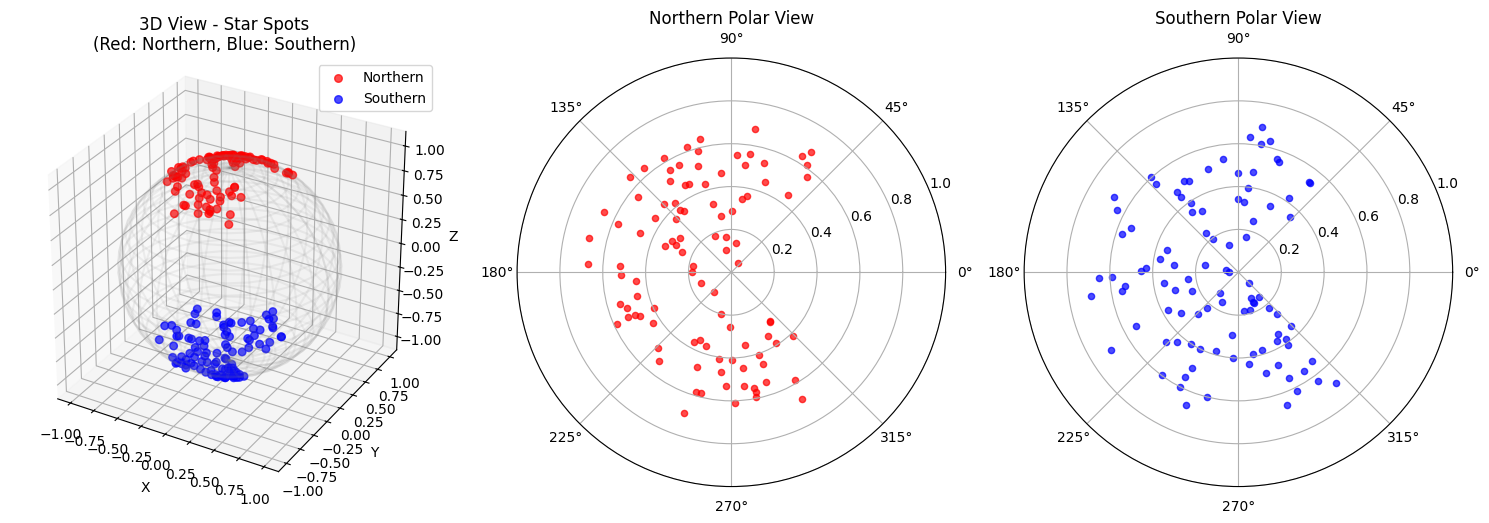

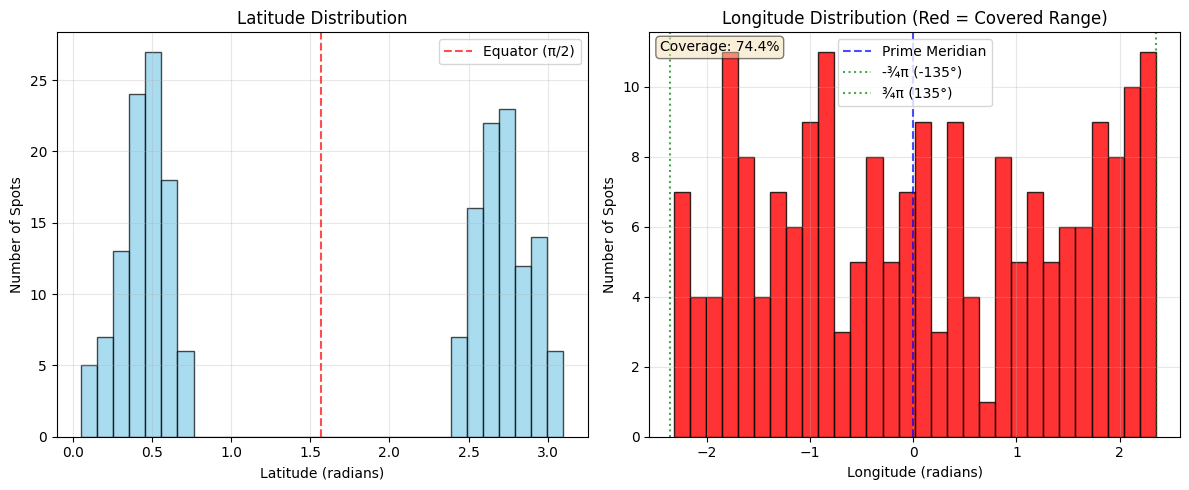

STAR SPOTS STATISTICS
Total spots generated: 200
Northern hemisphere spots: 100
Southern hemisphere spots: 100

Latitude Statistics (radians):
  Min latitude: 0.052083 rad (3.0°)
  Max latitude: 3.099415 rad (177.6°)
  Mean latitude: 1.587638 rad (91.0°)

Northern Polar Cap (0 to 1.0 rad from pole):
  Spots in region: 100
  Min latitude: 0.052083 rad (3.0°)
  Max latitude: 0.691059 rad (39.6°)

Southern Polar Cap (π-1.0 to π rad from pole):
  Spots in region: 100
  Min latitude: 2.443370 rad (140.0°)
  Max latitude: 3.099415 rad (177.6°)

Longitude Statistics (radians):
  Min longitude: -2.323858 rad (-133.1°)
  Max longitude: 2.351107 rad (134.7°)
  Coverage: 74.4% of full sphere
  Expected: 75.0% of full sphere (-¾π to ¾π)
  Standard deviation: 1.407241 rad
  Uniformity check: 200 unique longitudes


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def random_band_spots(N_per_band, 
                      north_min_lat=0.0, 
                      north_max_lat=np.pi/2, 
                      south_min_lat=np.pi/2, 
                      south_max_lat=np.pi,
                      generate_north=True,
                      generate_south=True):
    """
    Generate spots in latitude bands with random placement in both latitude and longitude.
    
    Parameters:
    - N_per_band: number of spots per hemisphere band
    - north_min_lat, north_max_lat: latitude bounds for northern hemisphere (radians from north pole)
    - south_min_lat, south_max_lat: latitude bounds for southern hemisphere (radians from north pole)
    - generate_north: if True, generate spots in northern hemisphere
    - generate_south: if True, generate spots in southern hemisphere
    
    Returns:
    - latitudes, longitudes in radians
    """
    all_latitudes = []
    all_longitudes = []
    
    # Longitude range: -(3/4)π to (3/4)π
    lon_min = -(3/4) * np.pi
    lon_max = (3/4) * np.pi
    lon_range = lon_max - lon_min
    
    if generate_north:
        # Generate random latitudes in the northern band
        # Using the same cosine transformation for uniform distribution on sphere
        cos_north_min = np.cos(north_min_lat)
        cos_north_max = np.cos(north_max_lat)
        
        # Random uniform distribution in cosine space
        cos_theta_north = cos_north_min - (cos_north_min - cos_north_max) * np.random.rand(N_per_band)
        latitudes_north = np.arccos(cos_theta_north)  # [0, π/2] from north pole
        
        # Random longitudes within -(3/4)π to (3/4)π
        longitudes_north = lon_min + np.random.rand(N_per_band) * lon_range
        
        all_latitudes.append(latitudes_north)
        all_longitudes.append(longitudes_north)
    
    if generate_south:
        # Generate random latitudes in the southern band
        cos_south_min = np.cos(south_min_lat)
        cos_south_max = np.cos(south_max_lat)
        
        # Random uniform distribution in cosine space
        cos_theta_south = cos_south_min - (cos_south_min - cos_south_max) * np.random.rand(N_per_band)
        latitudes_south = np.arccos(cos_theta_south)  # This gives angles from north pole
        
        # Convert to southern hemisphere (mirror across equator if needed)
        # If south_min_lat > π/2, we need to ensure we're in southern hemisphere
        if south_min_lat > np.pi/2:
            # We're already in southern hemisphere with arccos
            pass
        else:
            # Mirror to southern hemisphere
            latitudes_south = np.pi - latitudes_south
        
        # Random longitudes within -(3/4)π to (3/4)π
        longitudes_south = lon_min + np.random.rand(N_per_band) * lon_range
        
        all_latitudes.append(latitudes_south)
        all_longitudes.append(longitudes_south)
    
    if all_latitudes:
        latitudes = np.concatenate(all_latitudes)
        longitudes = np.concatenate(all_longitudes)
    else:
        latitudes = np.array([])
        longitudes = np.array([])
    
    return latitudes, longitudes


# Keep all the existing helper functions unchanged:
def write_spots_to_file(latitudes, longitudes, filename, metadata=None):
    """ (unchanged) """
    with open(filename, 'w') as f:
        f.write("# Star Spot Coordinates (radians)\n")
        f.write(f"# Number of spots: {len(latitudes)}\n")
        f.write(f"# Latitude range: {latitudes.min():.6f} to {latitudes.max():.6f} rad\n")
        f.write(f"# Longitude range: {longitudes.min():.6f} to {longitudes.max():.6f} rad\n")
        
        # Calculate coverage percentage
        coverage = (longitudes.max() - longitudes.min()) / (2 * np.pi) * 100
        f.write(f"# Coverage: {coverage:.1f}% of full sphere\n")
        
        if metadata:
            for key, value in metadata.items():
                f.write(f"# {key}: {value}\n")
        
        f.write("# Columns: latitude, longitude\n")
        
        for lat, lon in zip(latitudes, longitudes):
            f.write(f"{lat:.10f} {lon:.10f}\n")
    
    print(f"Spot coordinates written to {filename}")

def read_spots_from_file(filename):
    """ (unchanged) """
    latitudes = []
    longitudes = []
    metadata = {}
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            if not line or line.startswith('#'):
                if line.startswith('#') and ':' in line:
                    key_value = line[1:].split(':', 1)
                    if len(key_value) == 2:
                        key = key_value[0].strip()
                        value = key_value[1].strip()
                        metadata[key] = value
                continue
            
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    latitudes.append(lat)
                    longitudes.append(lon)
                except ValueError:
                    continue
    
    latitudes = np.array(latitudes)
    longitudes = np.array(longitudes)
    
    return latitudes, longitudes, metadata

def spherical_to_cartesian(latitudes, longitudes, radius=1.0):
    """ (unchanged) """
    theta = latitudes
    phi = longitudes + np.pi
    
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    
    return x, y, z

def plot_3d_sphere(latitudes, longitudes):
    """ (unchanged) """
    x, y, z = spherical_to_cartesian(latitudes, longitudes)
    
    northern = latitudes < np.pi/2
    southern = latitudes > np.pi/2
    
    fig = plt.figure(figsize=(15, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    
    if np.any(northern):
        ax1.scatter(x[northern], y[northern], z[northern], s=30, alpha=0.7, c='red', label='Northern')
    
    if np.any(southern):
        ax1.scatter(x[southern], y[southern], z[southern], s=30, alpha=0.7, c='blue', label='Southern')
    
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    sphere_x = np.outer(np.cos(u), np.sin(v))
    sphere_y = np.outer(np.sin(u), np.sin(v))
    sphere_z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax1.plot_wireframe(sphere_x, sphere_y, sphere_z, color='gray', alpha=0.1)
    
    ax1.set_box_aspect([1, 1, 1])
    ax1.set_title('3D View - Star Spots\n(Red: Northern, Blue: Southern)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()
    
    ax2 = fig.add_subplot(132, projection='polar')
    if np.any(northern):
        theta_north = longitudes[northern] + np.pi
        r_north = latitudes[northern]
        ax2.scatter(theta_north, r_north, alpha=0.7, c='red', s=20)
        ax2.set_rmax(max(1.0, r_north.max()))
        ax2.set_title('Northern Polar View')
        ax2.grid(True)
    else:
        ax2.set_title('No Northern Spots')
    
    ax3 = fig.add_subplot(133, projection='polar')
    if np.any(southern):
        theta_south = longitudes[southern] + np.pi
        r_south = np.pi - latitudes[southern]
        ax3.scatter(theta_south, r_south, alpha=0.7, c='blue', s=20)
        ax3.set_rmax(max(1.0, r_south.max()))
        ax3.set_title('Southern Polar View')
        ax3.grid(True)
    else:
        ax3.set_title('No Southern Spots')
    
    plt.tight_layout()
    plt.savefig('band_spot_projection.png', dpi=300)
    plt.show()

def plot_distributions(latitudes, longitudes):
    """ Plot with longitude boundaries highlighted """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Latitude histogram
    ax1.hist(latitudes, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(np.pi/2, color='red', linestyle='--', alpha=0.7, label='Equator (π/2)')
    ax1.set_xlabel('Latitude (radians)')
    ax1.set_ylabel('Number of Spots')
    ax1.set_title('Latitude Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Longitude histogram with boundaries
    n_bins = 30
    counts, bins, patches = ax2.hist(longitudes, bins=n_bins, alpha=0.7, color='orange', edgecolor='black')
    
    # Highlight the range -0.75π to 0.75π
    for i, (bin_left, bin_right) in enumerate(zip(bins[:-1], bins[1:])):
        if bin_left >= -(3/4)*np.pi and bin_right <= (3/4)*np.pi:
            patches[i].set_facecolor('red')
            patches[i].set_alpha(0.8)
    
    ax2.axvline(0, color='blue', linestyle='--', alpha=0.7, label='Prime Meridian')
    ax2.axvline(-(3/4)*np.pi, color='green', linestyle=':', alpha=0.7, label='-¾π (-135°)')
    ax2.axvline((3/4)*np.pi, color='green', linestyle=':', alpha=0.7, label='¾π (135°)')
    
    coverage = (longitudes.max() - longitudes.min()) / (2 * np.pi) * 100
    ax2.text(0.02, 0.98, f'Coverage: {coverage:.1f}%', 
             transform=ax2.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax2.set_xlabel('Longitude (radians)')
    ax2.set_ylabel('Number of Spots')
    ax2.set_title('Longitude Distribution (Red = Covered Range)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('band_spot_distributions.png', dpi=300)
    plt.show()

def print_statistics(latitudes, longitudes):
    """ Enhanced statistics with coverage info """
    print("=" * 50)
    print("STAR SPOTS STATISTICS")
    print("=" * 50)
    
    print(f"Total spots generated: {len(latitudes)}")
    print(f"Northern hemisphere spots: {np.sum(latitudes < np.pi/2)}")
    print(f"Southern hemisphere spots: {np.sum(latitudes > np.pi/2)}")
    print()
    
    print("Latitude Statistics (radians):")
    print(f"  Min latitude: {latitudes.min():.6f} rad ({np.degrees(latitudes.min()):.1f}°)")
    print(f"  Max latitude: {latitudes.max():.6f} rad ({np.degrees(latitudes.max()):.1f}°)")
    print(f"  Mean latitude: {latitudes.mean():.6f} rad ({np.degrees(latitudes.mean()):.1f}°)")
    print()
    
    northern_polar = latitudes[latitudes < 1.0]
    southern_polar = latitudes[latitudes > (np.pi - 1.0)]
    
    print("Northern Polar Cap (0 to 1.0 rad from pole):")
    if len(northern_polar) > 0:
        print(f"  Spots in region: {len(northern_polar)}")
        print(f"  Min latitude: {northern_polar.min():.6f} rad ({np.degrees(northern_polar.min()):.1f}°)")
        print(f"  Max latitude: {northern_polar.max():.6f} rad ({np.degrees(northern_polar.max()):.1f}°)")
    else:
        print(f"  Spots in region: 0")
    print()
    
    print("Southern Polar Cap (π-1.0 to π rad from pole):")
    if len(southern_polar) > 0:
        print(f"  Spots in region: {len(southern_polar)}")
        print(f"  Min latitude: {southern_polar.min():.6f} rad ({np.degrees(southern_polar.min()):.1f}°)")
        print(f"  Max latitude: {southern_polar.max():.6f} rad ({np.degrees(southern_polar.max()):.1f}°)")
    else:
        print(f"  Spots in region: 0")
    print()
    
    print("Longitude Statistics (radians):")
    print(f"  Min longitude: {longitudes.min():.6f} rad ({np.degrees(longitudes.min()):.1f}°)")
    print(f"  Max longitude: {longitudes.max():.6f} rad ({np.degrees(longitudes.max()):.1f}°)")
    
    coverage = (longitudes.max() - longitudes.min()) / (2 * np.pi) * 100
    print(f"  Coverage: {coverage:.1f}% of full sphere")
    print(f"  Expected: 75.0% of full sphere (-¾π to ¾π)")
    
    print(f"  Standard deviation: {longitudes.std():.6f} rad")
    
    unique_lons = len(np.unique(np.round(longitudes, 6)))
    print(f"  Uniformity check: {unique_lons} unique longitudes")


# Example usage:
if __name__ == "__main__":
    print("Generating spots with longitude range: -(3/4)π to (3/4)π")
    print("This is -135° to +135°, covering 75% of the stellar surface")
    print("The back of the star (±π to ±¾π) is not covered with spots")
    print()
    
    # Generate spots in specific latitude bands
    # Northern band: 0 to 40 degrees (0 to 0.698 rad)
    # Southern band: 140 to 180 degrees (2.443 to 3.142 rad)
    latitudes, longitudes = random_band_spots(
        N_per_band=100,
        north_min_lat=0.0,
        north_max_lat=0.698,  # 40 degrees
        south_min_lat=2.443,   # 140 degrees
        south_max_lat=np.pi,   # 180 degrees
        generate_north=True,
        generate_south=True
    )
    
    # Save to file with metadata
    metadata = {
        "Method": "random_band_spots",
        "Longitude range": "-(3/4)π to (3/4)π",
        "Coverage": "75% of full sphere",
        "Uncovered region": "±¾π to ±π (back of star)",
        "Northern min latitude": "0.0 rad",
        "Northern max latitude": "0.698 rad (40°)",
        "Southern min latitude": "2.443 rad (140°)",
        "Southern max latitude": "π rad (180°)"
    }
    
    write_spots_to_file(latitudes, longitudes, "band_spots_75percent.txt", metadata)
    
    # Visualize
    plot_3d_sphere(latitudes, longitudes)
    plot_distributions(latitudes, longitudes)
    
    # Print statistics
    print_statistics(latitudes, longitudes)

Reading spot data from band_spots_75percent.txt...
Successfully loaded 200 spots into JAX arrays
Latitudes shape: (200,), dtype: float32
Longitudes shape: (200,), dtype: float32


Generating histograms...


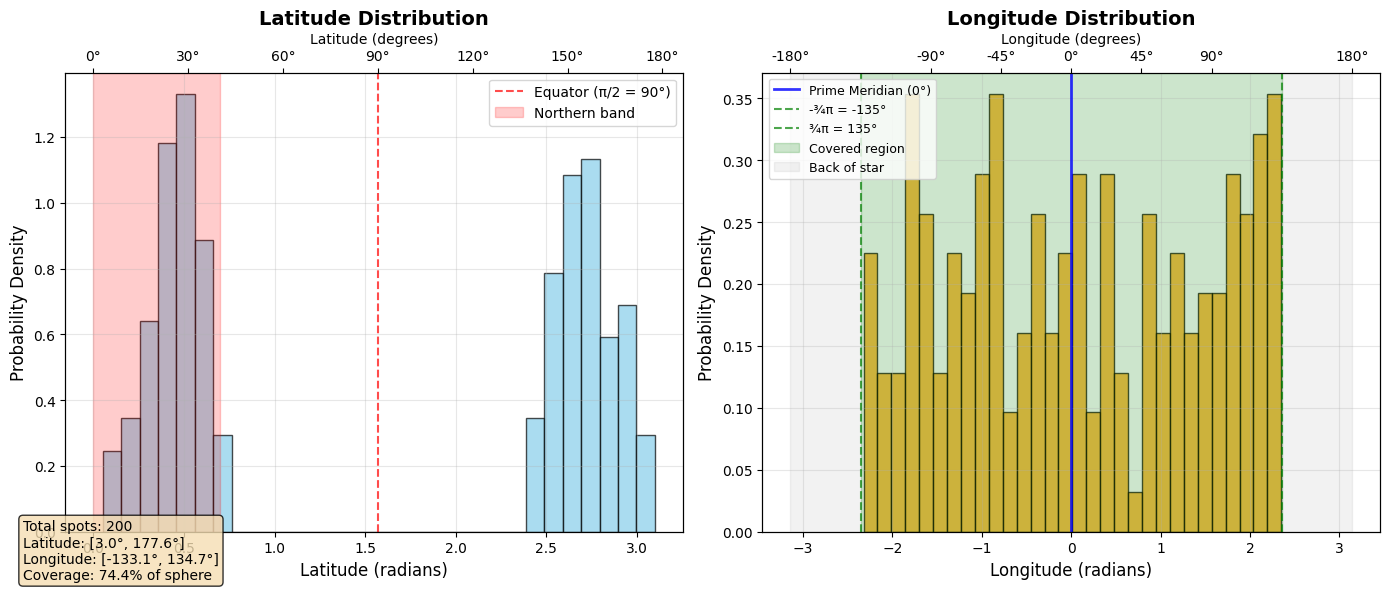

In [15]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# First, let's read the file and load the data
def read_spots_file_to_jax(filename):
    """
    Read spot coordinates from a file and return as JAX arrays.
    
    Parameters:
    - filename: input filename
    
    Returns:
    - latitudes, longitudes as JAX arrays
    - metadata dictionary
    """
    latitudes = []
    longitudes = []
    metadata = {}
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            if not line or line.startswith('#'):
                if line.startswith('#') and ':' in line:
                    key_value = line[1:].split(':', 1)
                    if len(key_value) == 2:
                        key = key_value[0].strip()
                        value = key_value[1].strip()
                        metadata[key] = value
                continue
            
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    latitudes.append(lat)
                    longitudes.append(lon)
                except ValueError:
                    continue
    
    # Convert to JAX arrays
    latitudes_jax = jnp.array(latitudes)
    longitudes_jax = jnp.array(longitudes)
    
    return latitudes_jax, longitudes_jax, metadata

# Now let's plot histograms
def plot_jax_histograms(latitudes_jax, longitudes_jax, metadata=None):
    """
    Create a 2-panel histogram showing latitude and longitude distributions.
    
    Parameters:
    - latitudes_jax: JAX array of latitudes in radians
    - longitudes_jax: JAX array of longitudes in radians
    - metadata: dictionary with metadata from the file
    """
    
    # Convert JAX arrays to NumPy for plotting (matplotlib doesn't handle JAX arrays directly)
    latitudes_np = np.array(latitudes_jax)
    longitudes_np = np.array(longitudes_jax)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel 1: Latitude histogram
    n_bins_lat = 30
    ax1.hist(latitudes_np, bins=n_bins_lat, alpha=0.7, color='skyblue', 
             edgecolor='black', density=True)
    ax1.axvline(np.pi/2, color='red', linestyle='--', alpha=0.7, 
                label='Equator (π/2 = 90°)')
    
    # Add expected latitude bands if in metadata
    if metadata:
        if 'Northern min latitude' in metadata and 'Northern max latitude' in metadata:
            try:
                north_min = float(metadata['Northern min latitude'].split()[0])
                north_max = float(metadata['Northern max latitude'].split()[0])
                ax1.axvspan(north_min, north_max, alpha=0.2, color='red', 
                           label='Northern band')
            except:
                pass
        
        if 'Southern min latitude' in metadata and 'Southern max latitude' in metadata:
            try:
                south_min = float(metadata['Southern min latitude'].split()[0])
                south_max = float(metadata['Southern max latitude'].split()[0])
                ax1.axvspan(south_min, south_max, alpha=0.2, color='blue', 
                           label='Southern band')
            except:
                pass
    
    ax1.set_xlabel('Latitude (radians)', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.set_title('Latitude Distribution', fontsize=14, fontweight='bold')
    
    # Add secondary x-axis with degrees
    ax1_deg = ax1.twiny()
    lat_ticks_rad = np.array([0, np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3, 5*np.pi/6, np.pi])
    lat_ticks_deg = np.degrees(lat_ticks_rad)
    ax1_deg.set_xlim(ax1.get_xlim())
    ax1_deg.set_xticks(lat_ticks_rad)
    ax1_deg.set_xticklabels([f'{d:.0f}°' for d in lat_ticks_deg])
    ax1_deg.set_xlabel('Latitude (degrees)', fontsize=10)
    
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Longitude histogram
    n_bins_lon = 30
    ax2.hist(longitudes_np, bins=n_bins_lon, alpha=0.7, color='orange', 
             edgecolor='black', density=True)
    ax2.axvline(0, color='blue', linestyle='-', alpha=0.8, 
                linewidth=2, label='Prime Meridian (0°)')
    
    # Mark the expected longitude boundaries
    expected_min = -(3/4) * np.pi
    expected_max = (3/4) * np.pi
    ax2.axvline(expected_min, color='green', linestyle='--', alpha=0.7, 
                label=f'-¾π = {np.degrees(expected_min):.0f}°')
    ax2.axvline(expected_max, color='green', linestyle='--', alpha=0.7, 
                label=f'¾π = {np.degrees(expected_max):.0f}°')
    
    # Highlight the covered region
    ax2.axvspan(expected_min, expected_max, alpha=0.2, color='green', 
                label='Covered region')
    
    # Mark the "back" of the star (uncovered regions)
    ax2.axvspan(-np.pi, expected_min, alpha=0.1, color='gray', 
                label='Back of star')
    ax2.axvspan(expected_max, np.pi, alpha=0.1, color='gray')
    
    ax2.set_xlabel('Longitude (radians)', fontsize=12)
    ax2.set_ylabel('Probability Density', fontsize=12)
    ax2.set_title('Longitude Distribution', fontsize=14, fontweight='bold')
    
    # Add secondary x-axis with degrees
    ax2_deg = ax2.twiny()
    lon_ticks_rad = np.array([-np.pi, -np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2, np.pi])
    lon_ticks_deg = np.degrees(lon_ticks_rad)
    ax2_deg.set_xlim(ax2.get_xlim())
    ax2_deg.set_xticks(lon_ticks_rad)
    ax2_deg.set_xticklabels([f'{d:.0f}°' for d in lon_ticks_deg])
    ax2_deg.set_xlabel('Longitude (degrees)', fontsize=10)
    
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = f'Total spots: {len(latitudes_np):,}\n'
    stats_text += f'Latitude: [{np.degrees(latitudes_np.min()):.1f}°, {np.degrees(latitudes_np.max()):.1f}°]\n'
    stats_text += f'Longitude: [{np.degrees(longitudes_np.min()):.1f}°, {np.degrees(longitudes_np.max()):.1f}°]\n'
    stats_text += f'Coverage: {(longitudes_np.max() - longitudes_np.min())/(2*np.pi)*100:.1f}% of sphere'
    
    # Position the text box
    fig.text(0.02, 0.02, stats_text, transform=fig.transFigure, 
             fontsize=10, verticalalignment='bottom',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('jax_spot_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, (ax1, ax2)

# Let's also create a function to print statistics from JAX arrays
def print_jax_statistics(latitudes_jax, longitudes_jax, metadata=None):
    """
    Print detailed statistics from JAX arrays.
    
    Parameters:
    - latitudes_jax: JAX array of latitudes in radians
    - longitudes_jax: JAX array of longitudes in radians
    - metadata: dictionary with metadata from the file
    """
    
    print("=" * 60)
    print("SPOT STATISTICS FROM JAX ARRAYS")
    print("=" * 60)
    
    # Convert to numpy for easier printing (JAX arrays don't have .min()/.max() directly)
    latitudes_np = np.array(latitudes_jax)
    longitudes_np = np.array(longitudes_jax)
    
    print(f"Total spots: {len(latitudes_np)}")
    print(f"Northern hemisphere spots: {np.sum(latitudes_np < np.pi/2)}")
    print(f"Southern hemisphere spots: {np.sum(latitudes_np > np.pi/2)}")
    print()
    
    print("Latitude Statistics:")
    print(f"  Min: {latitudes_np.min():.6f} rad ({np.degrees(latitudes_np.min()):.2f}°)")
    print(f"  Max: {latitudes_np.max():.6f} rad ({np.degrees(latitudes_np.max()):.2f}°)")
    print(f"  Mean: {latitudes_np.mean():.6f} rad ({np.degrees(latitudes_np.mean()):.2f}°)")
    print(f"  Std Dev: {latitudes_np.std():.6f} rad ({np.degrees(latitudes_np.std()):.2f}°)")
    print()
    
    print("Longitude Statistics:")
    print(f"  Min: {longitudes_np.min():.6f} rad ({np.degrees(longitudes_np.min()):.2f}°)")
    print(f"  Max: {longitudes_np.max():.6f} rad ({np.degrees(longitudes_np.max()):.2f}°)")
    print(f"  Mean: {longitudes_np.mean():.6f} rad ({np.degrees(longitudes_np.mean()):.2f}°)")
    print(f"  Std Dev: {longitudes_np.std():.6f} rad ({np.degrees(longitudes_np.std()):.2f}°)")
    
    coverage = (longitudes_np.max() - longitudes_np.min()) / (2 * np.pi) * 100
    print(f"  Coverage: {coverage:.2f}% of full sphere")
    print(f"  Expected: 75.00% of full sphere")
    print()
    
    # Show some JAX-specific information
    print("JAX Array Information:")
    print(f"  Latitudes dtype: {latitudes_jax.dtype}")
    print(f"  Longitudes dtype: {longitudes_jax.dtype}")
    print(f"  Latitudes shape: {latitudes_jax.shape}")
    print(f"  Longitudes shape: {longitudes_jax.shape}")
    print(f"  Device: {latitudes_jax.device()}")
    print()
    
    if metadata:
        print("File Metadata:")
        for key, value in metadata.items():
            print(f"  {key}: {value}")

# Example usage
if __name__ == "__main__":
    # Read the file we created earlier
    filename = "band_spots_75percent.txt"
    
    print(f"Reading spot data from {filename}...")
    latitudes_jax, longitudes_jax, metadata = read_spots_file_to_jax(filename)
    
    print(f"Successfully loaded {len(latitudes_jax)} spots into JAX arrays")
    print(f"Latitudes shape: {latitudes_jax.shape}, dtype: {latitudes_jax.dtype}")
    print(f"Longitudes shape: {longitudes_jax.shape}, dtype: {longitudes_jax.dtype}")
    print()
    
    # Create histograms
    print("\nGenerating histograms...")
    fig, axes = plot_jax_histograms(latitudes_jax, longitudes_jax, metadata)